In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("stock_analysis_100_records.csv")

In [3]:
df

,Date,Open,High,Low,Close,Volume
0,2026-01-05,100.00,100.34,99.06,100.00,1035672
1,2026-01-06,99.15,100.87,97.93,99.85,610835
2,2026-01-07,99.60,102.35,99.35,101.12,760093
3,2026-01-08,100.91,104.43,99.89,103.99,850786
4,2026-01-09,103.49,104.70,102.45,103.65,857047
...,...,...,...,...,...,...
95,2026-05-18,87.80,88.30,85.11,85.49,1078468
96,2026-05-19,85.69,86.89,85.45,86.03,930836
97,2026-05-20,85.57,87.85,84.48,86.52,694413
98,2026-05-21,86.60,87.14,86.50,86.61,821449


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    100 non-null    object 
 1   Open    100 non-null    float64
 2   High    100 non-null    float64
 3   Low     100 non-null    float64
 4   Close   100 non-null    float64
 5   Volume  100 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 4.8+ KB


In [5]:
df["Date"]=pd.to_datetime(df["Date"])

In [6]:
df.dtypes

Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
dtype: object

In [7]:
df=df.sort_values("Date")

In [8]:
df["MA_20"]=df["Close"].rolling(20).mean()
df["MA_50"]=df["Close"].rolling(50).mean()
df

,Date,Open,High,Low,Close,Volume,MA_20,MA_50
0,2026-01-05,100.00,100.34,99.06,100.00,1035672,NaN,NaN
1,2026-01-06,99.15,100.87,97.93,99.85,610835,NaN,NaN
2,2026-01-07,99.60,102.35,99.35,101.12,760093,NaN,NaN
3,2026-01-08,100.91,104.43,99.89,103.99,850786,NaN,NaN
4,2026-01-09,103.49,104.70,102.45,103.65,857047,NaN,NaN
...,...,...,...,...,...,...,...,...
95,2026-05-18,87.80,88.30,85.11,85.49,1078468,87.9065,87.3316
96,2026-05-19,85.69,86.89,85.45,86.03,930836,87.6480,87.3552
97,2026-05-20,85.57,87.85,84.48,86.52,694413,87.4340,87.3546
98,2026-05-21,86.60,87.14,86.50,86.61,821449,87.2125,87.3434


In [9]:
df["Daily_Return"]=(df["Close"]/df["Open"])*100

In [10]:
df

,Date,Open,High,Low,Close,Volume,MA_20,MA_50,Daily_Return
0,2026-01-05,100.00,100.34,99.06,100.00,1035672,NaN,NaN,100.000000
1,2026-01-06,99.15,100.87,97.93,99.85,610835,NaN,NaN,100.706001
2,2026-01-07,99.60,102.35,99.35,101.12,760093,NaN,NaN,101.526104
3,2026-01-08,100.91,104.43,99.89,103.99,850786,NaN,NaN,103.052225
4,2026-01-09,103.49,104.70,102.45,103.65,857047,NaN,NaN,100.154604
...,...,...,...,...,...,...,...,...,...
95,2026-05-18,87.80,88.30,85.11,85.49,1078468,87.9065,87.3316,97.369021
96,2026-05-19,85.69,86.89,85.45,86.03,930836,87.6480,87.3552,100.396779
97,2026-05-20,85.57,87.85,84.48,86.52,694413,87.4340,87.3546,101.110202
98,2026-05-21,86.60,87.14,86.50,86.61,821449,87.2125,87.3434,100.011547


In [11]:
#analys stock return distribution

mean_return=df["Daily_Return"].mean()
print("mean_return",mean_return)

variance_return=df["Daily_Return"].var()  
print("variance_return",variance_return)

standard_return=df["Daily_Return"].std()
print("standard_return",standard_return)

mean_return 99.85771580089671
variance_return 4.62632629899549
standard_return 2.150889652910044


In [12]:
import matplotlib.pyplot as plt

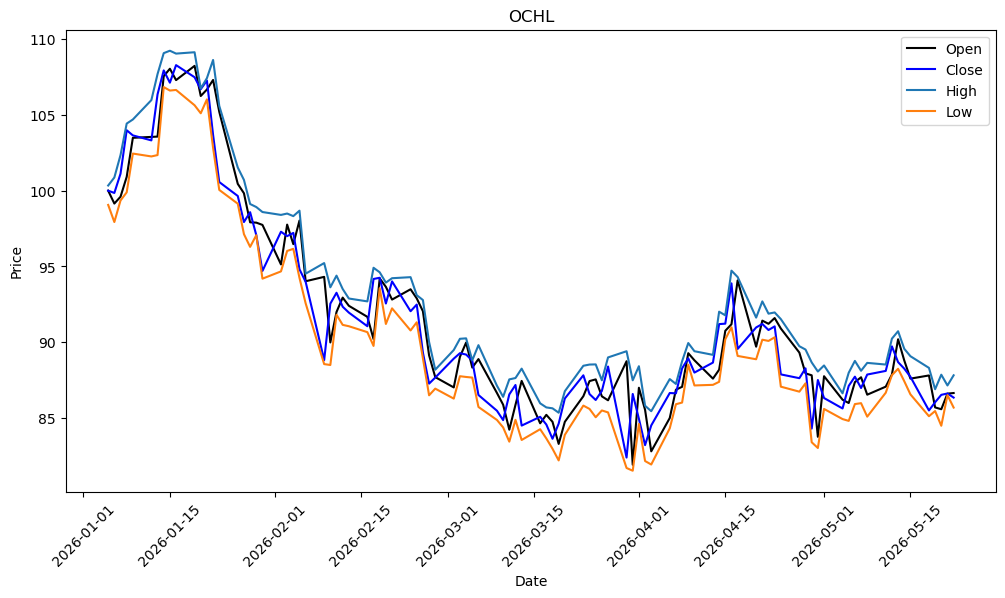

In [13]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"],df["Open"],label="Open",color="Black")
plt.plot(df["Date"],df["Close"],label="Close",color="Blue")
plt.plot(df["Date"],df["High"],label="High")
plt.plot(df["Date"],df["Low"],label="Low")
plt.title("OCHL")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()



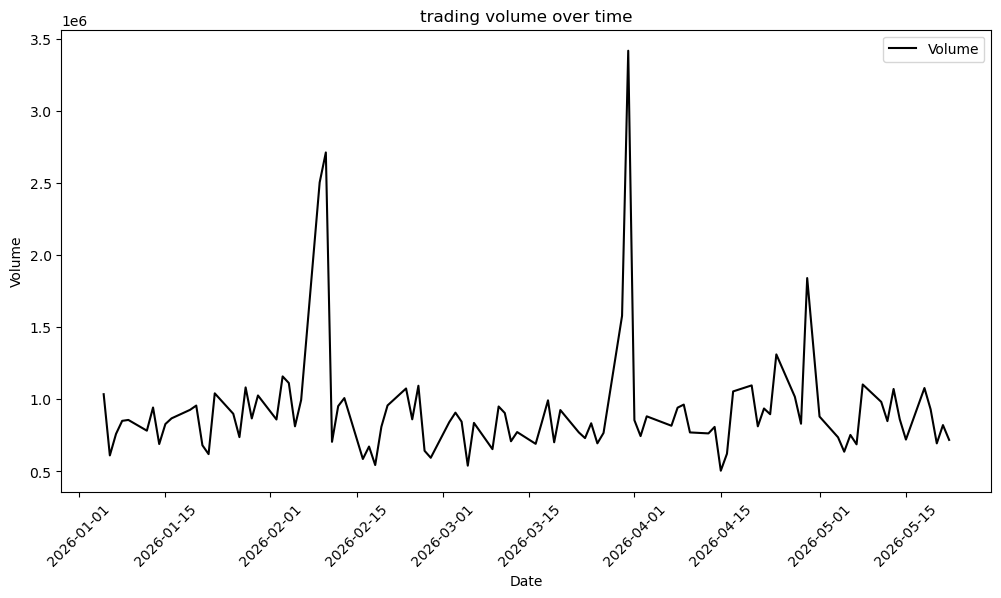

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(df["Date"],df["Volume"],label="Volume",color="Black")
plt.title("trading volume over time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.xticks(rotation=45)
plt.show()

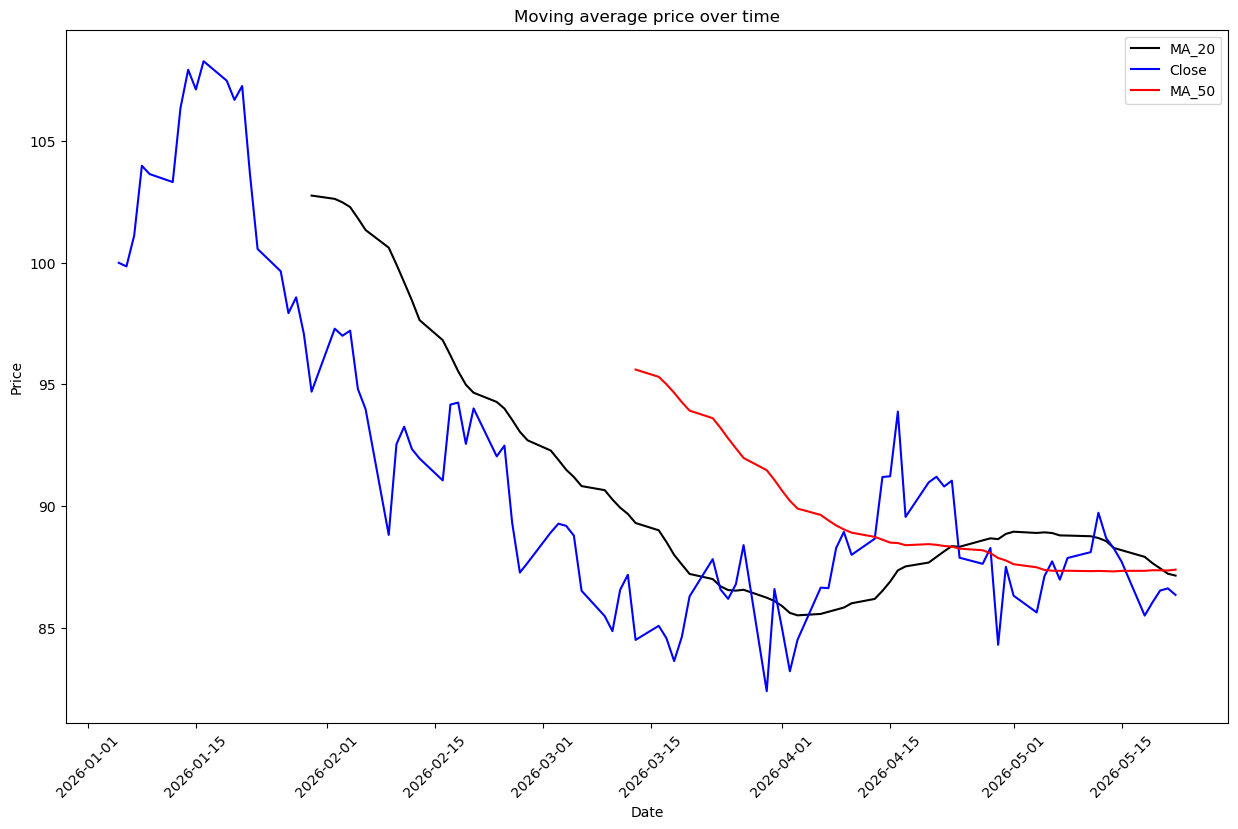

In [15]:
plt.figure(figsize=(15,9))
plt.plot(df["Date"],df["MA_20"],label="MA_20",color="Black")
plt.plot(df["Date"],df["Close"],label="Close",color="Blue")
plt.plot(df["Date"],df["MA_50"],label="MA_50",color="red")
plt.title("Moving average price over time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [16]:
import seaborn as sns

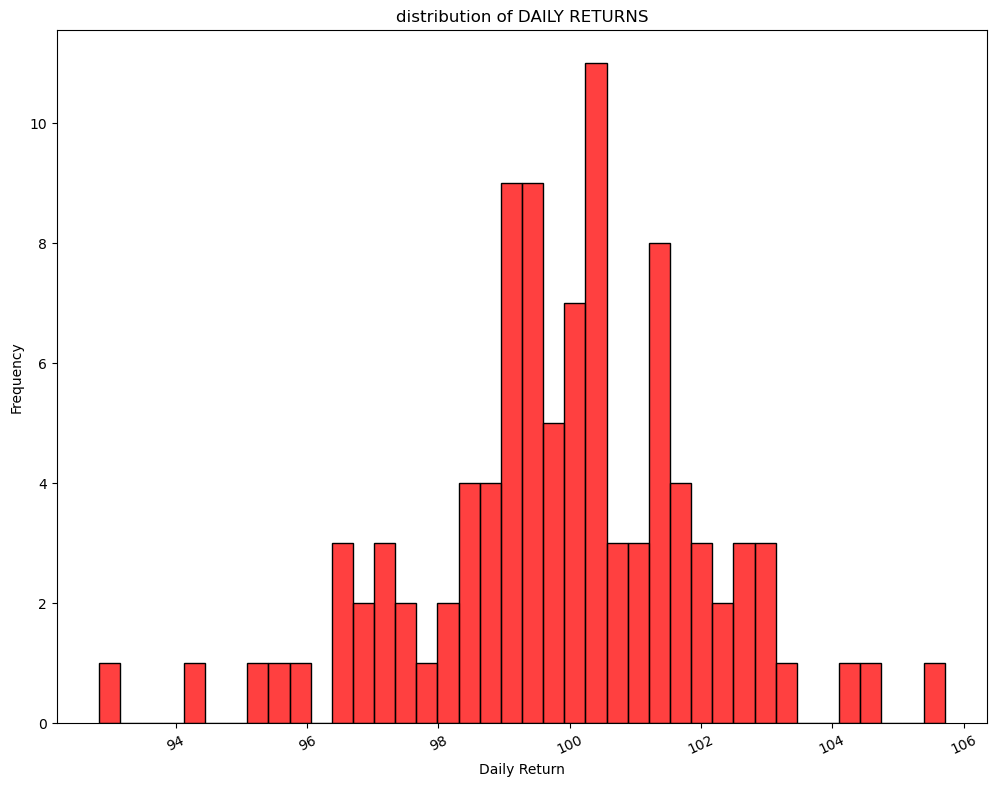

In [17]:
plt.figure(figsize=(12,9))
sns.histplot(df["Daily_Return"],bins=40,color="red")
plt.title("distribution of DAILY RETURNS")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.xticks(rotation=25)
plt.show()

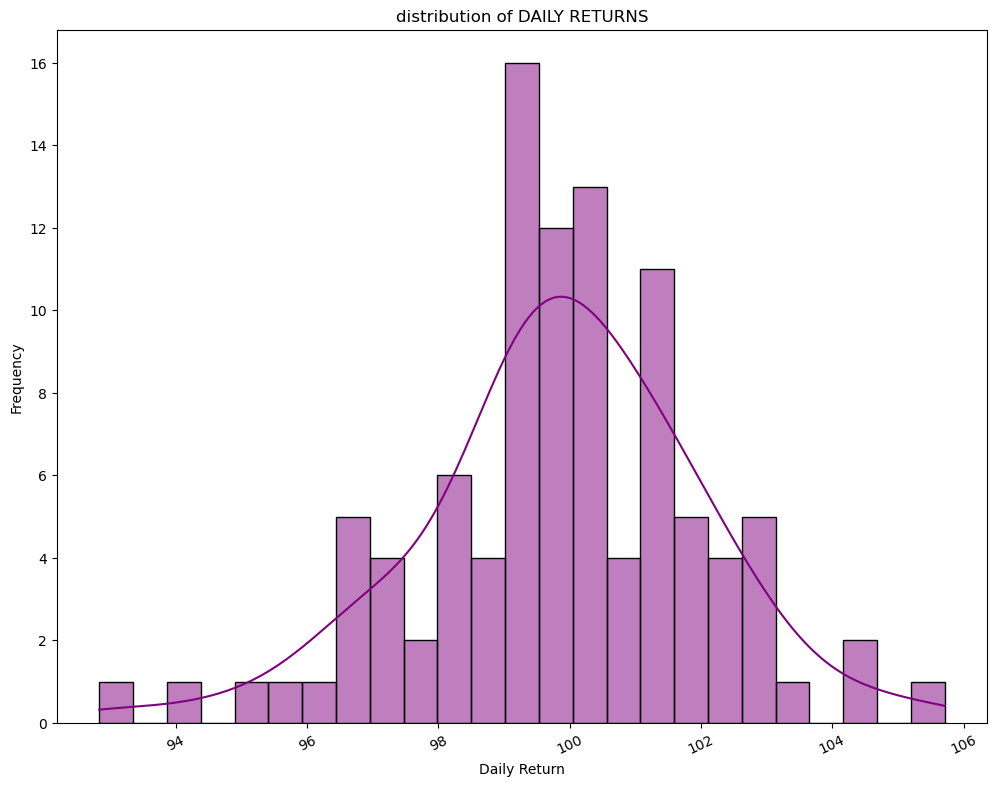

In [18]:
plt.figure(figsize=(12, 9))
sns.histplot(df["Daily_Return"], bins=25, kde=True, color="PURPLE")
plt.title("distribution of DAILY RETURNS")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.xticks(rotation=25)
plt.show()

In [20]:
avg_daily_return = df['Daily_Return'].mean()
variance = df['Daily_Return'].var()
std_deviation = df['Daily_Return'].std()
max_return = df['Daily_Return'].max()
min_return = df['Daily_Return'].min()

print("FINANCIAL SUMMARY")
print("*" * 30)
print("AVERAGE DAILY RETURNS:", avg_daily_return)
print("VARIANCE:", variance)
print("STANDARD DEVIATION:", std_deviation)
print("MAXIMUM DAILY RETURN:", max_return)
print("MINIMUM DAILY RETURN:", min_return)

FINANCIAL SUMMARY
******************************
AVERAGE DAILY RETURNS: 99.85771580089671
VARIANCE: 4.62632629899549
STANDARD DEVIATION: 2.150889652910044
MAXIMUM DAILY RETURN: 105.7142857142857
MINIMUM DAILY RETURN: 92.83299526707235
